# VISEM-Tracking — YOLOv8 versión rápida balanceada para Kaggle

Este notebook es una versión **más ligera y práctica** que el notebook mejorado pesado.

La idea es quedar en un punto medio:

- más rápido que `yolov8s.pt + imgsz=960 + 80 épocas`;
- mejor que el baseline inicial `yolov8n.pt + imgsz=640`, porque mantiene:
  - split por video;
  - corrección de `video_id`;
  - balanceo moderado de clases minoritarias;
  - `max_det=1000`;
  - evaluación en test;
  - predicciones visuales;
  - tracking opcional.

## Experimento por defecto

Este notebook corre por defecto:

```python
model = yolov8n.pt
imgsz = 768
epochs = 30
batch = 16
patience = 7
```

Esto debería tardar mucho menos que `yolov8s` a 960. Si tienes tiempo extra, puedes activar el experimento opcional `yolov8s_img640_fast_balanced`.

## Antes de correr en Kaggle

Activa:

- **Internet = On**
- **Accelerator = GPU T4** o superior


## 1. Instalación e imports

In [1]:
!pip -q install ultralytics scikit-learn opencv-python tqdm pandas matplotlib pyyaml lap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import os
import shutil
import random
import zipfile
import subprocess
import yaml
import re
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Setup listo")

Setup listo


## 2. Configuración general

El dataset oficial se descarga desde Zenodo. Si el ZIP ya existe en `/kaggle/working`, no se descarga de nuevo.

In [3]:
WORK_DIR = Path("/kaggle/working")
ZIP_PATH = WORK_DIR / "VISEM-Tracking.zip"
EXTRACT_DIR = WORK_DIR / "VISEM-Tracking"
YOLO_DIR = WORK_DIR / "yolo_visem_fast_balanced"

ZENODO_URL = "https://zenodo.org/records/7293726/files/VISEM-Tracking.zip?download=1"

CLASS_NAMES = {
    0: "sperm",
    1: "cluster",
    2: "small_or_pinhead"
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}

print("WORK_DIR:", WORK_DIR)
print("ZIP_PATH:", ZIP_PATH)
print("EXTRACT_DIR:", EXTRACT_DIR)
print("YOLO_DIR:", YOLO_DIR)


WORK_DIR: /kaggle/working
ZIP_PATH: /kaggle/working/VISEM-Tracking.zip
EXTRACT_DIR: /kaggle/working/VISEM-Tracking
YOLO_DIR: /kaggle/working/yolo_visem_fast_balanced


## 3. Descargar y descomprimir dataset

In [4]:
if ZIP_PATH.exists():
    print(f"El ZIP ya existe: {ZIP_PATH}")
    print(f"Tamaño actual: {ZIP_PATH.stat().st_size / (1024**3):.2f} GB")
else:
    print("Descargando VISEM-Tracking desde Zenodo...")
    cmd = [
        "wget",
        "-q",
        "-c",
        "-O", str(ZIP_PATH),
        ZENODO_URL
    ]
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
    print("Descarga finalizada")

print(f"Tamaño ZIP: {ZIP_PATH.stat().st_size / (1024**3):.2f} GB")

Descargando VISEM-Tracking desde Zenodo...
Descarga finalizada
Tamaño ZIP: 5.88 GB


In [5]:
if EXTRACT_DIR.exists() and any(EXTRACT_DIR.iterdir()):
    print(f"El dataset ya está descomprimido en: {EXTRACT_DIR}")
else:
    print("Descomprimiendo dataset...")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Descompresión finalizada")

print("Contenido principal:")
for item in sorted(EXTRACT_DIR.iterdir())[:30]:
    print("-", item.name)

Descomprimiendo dataset...
Descompresión finalizada
Contenido principal:
- VISEM_Tracking_Train_v4
- fatty_acids_serum_Train.csv
- fatty_acids_spermatoza_Train.csv
- participant_related_data_Train.csv
- semen_analysis_data_Train.csv
- sex_hormones_Train.csv
- sperm_counts_per_frame.csv
- visem-extracted-30s-excluding-selected-20
- visem-extracted-30s-selected-20-videos-excluding-first-30s


## 4. Inspección rápida de estructura

In [6]:
def show_tree(root: Path, max_depth=3, max_items_per_level=20):
    root = Path(root)
    base_depth = len(root.parts)

    for current_root, dirs, files in os.walk(root):
        current = Path(current_root)
        depth = len(current.parts) - base_depth

        if depth > max_depth:
            dirs[:] = []
            continue

        indent = "  " * depth
        print(f"{indent}{current.name}/")

        for f in files[:max_items_per_level]:
            print(f"{indent}  {f}")

        if len(files) > max_items_per_level:
            print(f"{indent}  ... {len(files) - max_items_per_level} archivos más")

show_tree(EXTRACT_DIR, max_depth=3)

VISEM-Tracking/
  fatty_acids_spermatoza_Train.csv
  semen_analysis_data_Train.csv
  sperm_counts_per_frame.csv
  fatty_acids_serum_Train.csv
  sex_hormones_Train.csv
  participant_related_data_Train.csv
  VISEM_Tracking_Train_v4/
    Train/
      35/
        35.mp4
        35.txt
      14/
        14.mp4
        14.txt
      47/
        47.mp4
        47.txt
      54/
        54.mp4
        54.txt
      15/
        15.mp4
        15.txt
      82/
        82.mp4
        82.txt
      36/
        36.mp4
        36.txt
      21/
        21.txt
        21.mp4
      30/
        30.mp4
        30.txt
      19/
        19.mp4
        19.txt
      60/
        60.mp4
        60.txt
      29/
        29.txt
        29.mp4
      13/
        13.txt
        13.mp4
      52/
        52.txt
        52.mp4
      24/
        24.mp4
        24.txt
      23/
        23.txt
        23.mp4
      38/
        38.mp4
        38.txt
      22/
        22.txt
        22.mp4
      12/
        12.mp4
        12.tx

## 5. Buscar imágenes y labels

A diferencia del primer notebook, aquí el `video_id` se calcula desde el principio usando la carpeta del video, por ejemplo `Train/11/images/...` produce `video_id = 11`.

In [7]:
all_images = sorted([p for p in EXTRACT_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS])
all_txts = sorted([p for p in EXTRACT_DIR.rglob("*.txt")])

print("Total imágenes encontradas:", len(all_images))
print("Total archivos .txt encontrados:", len(all_txts))

print("\nPrimeras imágenes:")
for p in all_images[:5]:
    print(p)

print("\nPrimeros labels:")
for p in all_txts[:5]:
    print(p)

Total imágenes encontradas: 29370
Total archivos .txt encontrados: 58412

Primeras imágenes:
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_0.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_10.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_100.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1000.jpg

Primeros labels:
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_0.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_1.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_10.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_100.txt


In [8]:
def infer_video_id(image_path):
    """
    Inferencia robusta del video_id.
    Caso típico: .../Train/11/images/11_frame_0.jpg -> 11
    """
    p = Path(image_path)
    parts = list(p.parts)

    if "images" in parts:
        idx = parts.index("images")
        if idx > 0:
            return parts[idx - 1]

    match = re.match(r"([A-Za-z]*\d+)[_\-]", p.stem)
    if match:
        return match.group(1)

    return p.parent.name


def find_label_for_image(img_path: Path):
    """Busca el label correspondiente a una imagen."""
    img_path = Path(img_path)

    # Caso 1: label en la misma carpeta
    direct = img_path.with_suffix(".txt")
    if direct.exists():
        return direct

    # Caso 2: estructura images/... y labels/...
    parts = list(img_path.parts)
    if "images" in parts:
        idx = parts.index("images")
        alt_parts = parts.copy()
        alt_parts[idx] = "labels"
        alt = Path(*alt_parts).with_suffix(".txt")
        if alt.exists():
            return alt

    return None

records = []
missing = []

for img in tqdm(all_images, desc="Asociando imágenes y labels"):
    label = find_label_for_image(img)
    if label is None:
        missing.append(img)
        continue

    records.append({
        "image_path": str(img),
        "label_path": str(label),
        "video_id": infer_video_id(img),
        "image_name": img.name
    })

df = pd.DataFrame(records)

print("Pares imagen-label encontrados:", len(df))
print("Imágenes sin label:", len(missing))
display(df.head())
print("\nVideos detectados:", df["video_id"].nunique())
print(sorted(df["video_id"].unique()))

Asociando imágenes y labels:   0%|          | 0/29370 [00:00<?, ?it/s]

Pares imagen-label encontrados: 29196
Imágenes sin label: 174


,image_path,label_path,video_id,image_name
0,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_0.jpg
1,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_1.jpg
2,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_10.jpg
3,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_100.jpg
4,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_1000.jpg



Videos detectados: 20
['11', '12', '13', '14', '15', '19', '21', '22', '23', '24', '29', '30', '35', '36', '38', '47', '52', '54', '60', '82']


In [9]:
if df.empty:
    raise RuntimeError("No se encontraron pares imagen-label. Revisa la estructura del dataset.")

print(df["video_id"].value_counts().sort_index())

video_id
11    1470
12    1470
13    1470
14    1470
15    1470
19    1470
21    1470
22    1470
23    1296
24    1470
29    1470
30    1470
35    1440
36    1470
38    1470
47    1470
52    1440
54    1470
60    1470
82    1500
Name: count, dtype: int64


## 6. Leer anotaciones YOLO y hacer EDA

In [10]:
def read_yolo_label(label_path):
    rows = []
    label_path = Path(label_path)

    if not label_path.exists():
        return rows

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            try:
                class_id = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:5])
            except ValueError:
                continue

            if class_id not in CLASS_NAMES:
                continue

            rows.append({
                "class_id": class_id,
                "x_center": x,
                "y_center": y,
                "width": w,
                "height": h,
                "area": w * h
            })

    return rows

ann_rows = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Leyendo labels"):
    anns = read_yolo_label(row["label_path"])
    for ann in anns:
        ann_rows.append({
            **ann,
            "image_path": row["image_path"],
            "label_path": row["label_path"],
            "video_id": row["video_id"],
            "image_name": row["image_name"]
        })

ann_df = pd.DataFrame(ann_rows)

print("Total anotaciones:", len(ann_df))
display(ann_df.head())

Leyendo labels:   0%|          | 0/29196 [00:00<?, ?it/s]

Total anotaciones: 656335


,class_id,x_center,y_center,width,height,area,image_path,label_path,video_id,image_name
0,0,0.275781,0.412500,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_0.jpg
1,0,0.238281,0.583333,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_0.jpg
2,0,0.246094,0.847917,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_0.jpg
3,0,0.194531,0.845833,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_0.jpg
4,0,0.083594,0.806250,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,11,11_frame_0.jpg


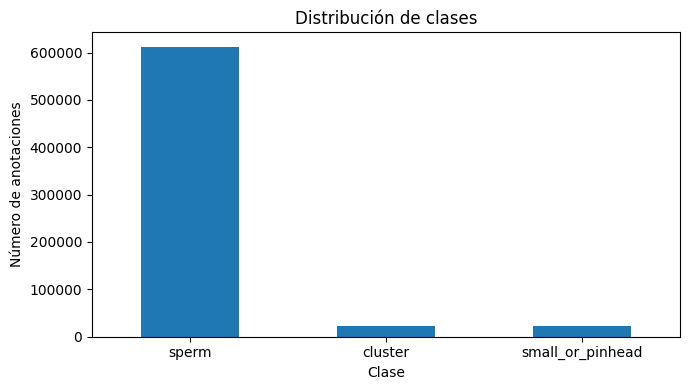

,count
sperm,612377
cluster,21846
small_or_pinhead,22112


,proportion
sperm,0.933025
cluster,0.033285
small_or_pinhead,0.033690


In [11]:
class_counts = ann_df["class_id"].value_counts().sort_index()
class_counts.index = [CLASS_NAMES.get(i, str(i)) for i in class_counts.index]

plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de anotaciones")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(class_counts.to_frame("count"))

display((class_counts / class_counts.sum()).to_frame("proportion"))

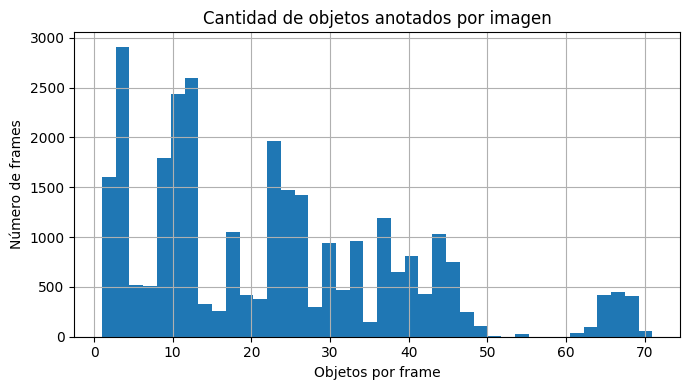

,objects_per_image
count,29196.000000
mean,22.480306
std,16.604505
min,1.000000
25%,9.000000
50%,21.000000
75%,34.000000
max,71.000000


In [12]:
boxes_per_image = ann_df.groupby("image_path").size()

plt.figure(figsize=(7, 4))
boxes_per_image.hist(bins=40)
plt.title("Cantidad de objetos anotados por imagen")
plt.xlabel("Objetos por frame")
plt.ylabel("Número de frames")
plt.tight_layout()
plt.show()

display(boxes_per_image.describe().to_frame("objects_per_image"))

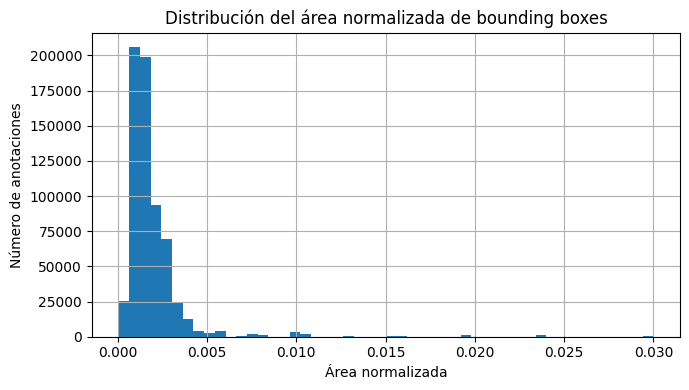

,normalized_area
count,656335.000000
mean,0.001959
std,0.002085
min,0.000052
25%,0.001088
50%,0.001504
75%,0.002187
max,0.029997


In [13]:
plt.figure(figsize=(7, 4))
ann_df["area"].hist(bins=50)
plt.title("Distribución del área normalizada de bounding boxes")
plt.xlabel("Área normalizada")
plt.ylabel("Número de anotaciones")
plt.tight_layout()
plt.show()

display(ann_df["area"].describe().to_frame("normalized_area"))

## 7. Visualizar ejemplos con bounding boxes reales

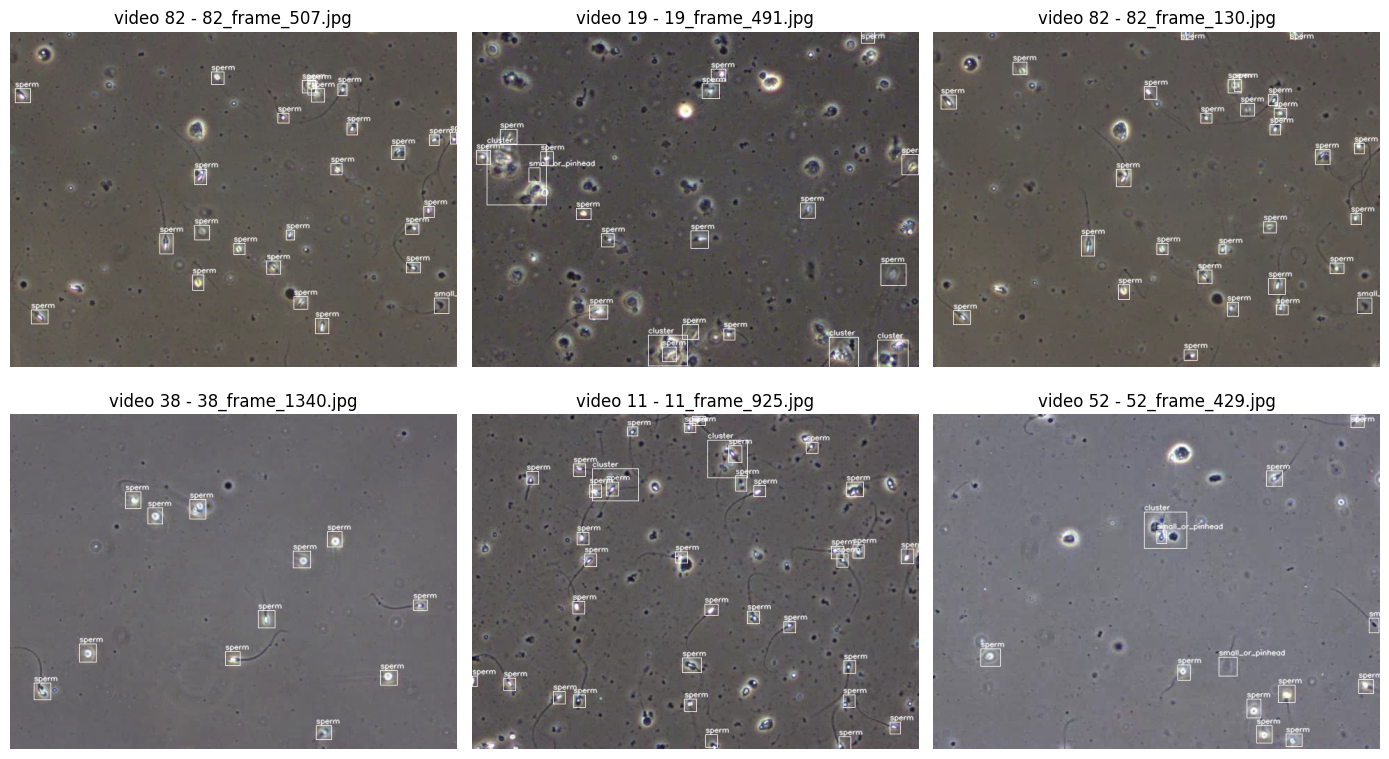

In [14]:
def draw_yolo_boxes(image_path, label_path, class_names):
    image_path = Path(image_path)
    label_path = Path(label_path)

    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    for ann in read_yolo_label(label_path):
        cls = ann["class_id"]
        x_center = ann["x_center"] * w
        y_center = ann["y_center"] * h
        bw = ann["width"] * w
        bh = ann["height"] * h

        x1 = int(x_center - bw / 2)
        y1 = int(y_center - bh / 2)
        x2 = int(x_center + bw / 2)
        y2 = int(y_center + bh / 2)

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), 1)
        cv2.putText(
            img,
            class_names.get(cls, str(cls)),
            (max(x1, 0), max(y1 - 3, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    return img

sample_df = df.sample(min(6, len(df)), random_state=SEED)

plt.figure(figsize=(14, 8))
for idx, (_, row) in enumerate(sample_df.iterrows(), 1):
    img = draw_yolo_boxes(row["image_path"], row["label_path"], CLASS_NAMES)
    plt.subplot(2, 3, idx)
    plt.imshow(img)
    plt.title(f"video {row['video_id']} - {row['image_name']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Split por video

La división se hace por video, no por frame. Esto evita que frames casi idénticos de un mismo video caigan simultáneamente en train y test.

Usamos el mismo `random_state=42` del primer notebook para mantener la comparación justa.

In [15]:
video_ids = sorted(df["video_id"].unique())
print("Videos detectados:", len(video_ids))
print(video_ids)

if len(video_ids) < 4:
    raise RuntimeError("Hay muy pocos videos para hacer split por video.")

train_videos, temp_videos = train_test_split(
    video_ids,
    test_size=0.30,
    random_state=SEED
)

val_videos, test_videos = train_test_split(
    temp_videos,
    test_size=0.50,
    random_state=SEED
)

split_map = {}
for v in train_videos:
    split_map[v] = "train"
for v in val_videos:
    split_map[v] = "val"
for v in test_videos:
    split_map[v] = "test"

df["split"] = df["video_id"].map(split_map)
ann_df["split"] = ann_df["video_id"].map(split_map)

print("\nVideos por split:")
print("train:", sorted(train_videos))
print("val:  ", sorted(val_videos))
print("test: ", sorted(test_videos))

print("\nImágenes por split:")
display(df["split"].value_counts().to_frame("images"))

split_summary = df.groupby(["split", "video_id"]).size().reset_index(name="num_frames")
display(split_summary.sort_values(["split", "video_id"]))

Videos detectados: 20
['11', '12', '13', '14', '15', '19', '21', '22', '23', '24', '29', '30', '35', '36', '38', '47', '52', '54', '60', '82']

Videos por split:
train: ['13', '14', '15', '21', '22', '24', '29', '30', '35', '36', '38', '52', '60', '82']
val:   ['12', '23', '47']
test:  ['11', '19', '54']

Imágenes por split:


,images
split,
train,20550
test,4410
val,4236


,split,video_id,num_frames
0,test,11,1470
1,test,19,1470
2,test,54,1470
3,train,13,1470
4,train,14,1470
5,train,15,1470
6,train,21,1470
7,train,22,1470
8,train,24,1470
9,train,29,1470


In [16]:
split_class_counts = (
    ann_df.groupby(["split", "class_id"])
    .size()
    .unstack(fill_value=0)
)
split_class_counts.columns = [CLASS_NAMES.get(c, str(c)) for c in split_class_counts.columns]

print("Conteo de anotaciones por split y clase:")
display(split_class_counts)

print("Proporción de clases por split:")
display(split_class_counts.div(split_class_counts.sum(axis=1), axis=0))

Conteo de anotaciones por split y clase:


,sperm,cluster,small_or_pinhead
split,,,
test,119137,11534,1170
train,448599,8842,16434
val,44641,1470,4508


Proporción de clases por split:


,sperm,cluster,small_or_pinhead
split,,,
test,0.903642,0.087484,0.008874
train,0.946661,0.018659,0.034680
val,0.881902,0.029040,0.089057


## 9. Crear dataset en formato YOLO

In [17]:
for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


def safe_copy(src, dst):
    src = Path(src)
    dst = Path(dst)
    if not dst.exists():
        shutil.copy2(src, dst)


def yolo_paths_for_row(row):
    split = row["split"]
    img_src = Path(row["image_path"])
    new_stem = f"{row['video_id']}__{img_src.stem}"
    img_dst = YOLO_DIR / "images" / split / f"{new_stem}{img_src.suffix.lower()}"
    lbl_dst = YOLO_DIR / "labels" / split / f"{new_stem}.txt"
    return img_dst, lbl_dst

image_dsts = []
label_dsts = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Copiando a formato YOLO"):
    img_src = Path(row["image_path"])
    lbl_src = Path(row["label_path"])
    img_dst, lbl_dst = yolo_paths_for_row(row)

    safe_copy(img_src, img_dst)
    safe_copy(lbl_src, lbl_dst)

    image_dsts.append(str(img_dst))
    label_dsts.append(str(lbl_dst))

df["yolo_image_path"] = image_dsts
df["yolo_label_path"] = label_dsts

print("Dataset YOLO creado en:", YOLO_DIR)
for split in ["train", "val", "test"]:
    n_imgs = len(list((YOLO_DIR / "images" / split).glob("*")))
    n_lbls = len(list((YOLO_DIR / "labels" / split).glob("*.txt")))
    print(f"{split}: {n_imgs} imágenes, {n_lbls} labels")

Copiando a formato YOLO:   0%|          | 0/29196 [00:00<?, ?it/s]

Dataset YOLO creado en: /kaggle/working/yolo_visem_fast_balanced
train: 20550 imágenes, 20550 labels
val: 4236 imágenes, 4236 labels
test: 4410 imágenes, 4410 labels


## 10. Crear train balanceado, pero sin hacerlo demasiado pesado

El notebook anterior usaba un sobremuestreo más agresivo. Eso puede mejorar las clases raras, pero también hace que cada época sea más larga.

Aquí hacemos un balanceo **moderado**:

- repetimos imágenes con `cluster`;
- repetimos más las imágenes con `small_or_pinhead`;
- pero limitamos el tamaño final del train a máximo `1.25x` el train original.

Así atacamos el desbalance sin volver lento cada epoch.


In [18]:
train_base = df[df["split"] == "train"]["yolo_image_path"].astype(str).tolist()

rare_cluster_original = set(
    ann_df[
        (ann_df["split"] == "train") &
        (ann_df["class_id"] == 1)
    ]["image_path"].unique()
)

rare_pinhead_original = set(
    ann_df[
        (ann_df["split"] == "train") &
        (ann_df["class_id"] == 2)
    ]["image_path"].unique()
)

cluster_imgs = df[
    (df["split"] == "train") &
    (df["image_path"].isin(rare_cluster_original))
]["yolo_image_path"].astype(str).tolist()

pinhead_imgs = df[
    (df["split"] == "train") &
    (df["image_path"].isin(rare_pinhead_original))
]["yolo_image_path"].astype(str).tolist()

# Balanceo moderado para no volver lentas las épocas.
# Estos valores son menores que los del notebook pesado.
CLUSTER_MULTIPLIER = 1
PINHEAD_MULTIPLIER = 3

extra_imgs = cluster_imgs * CLUSTER_MULTIPLIER + pinhead_imgs * PINHEAD_MULTIPLIER
random.shuffle(extra_imgs)

# Límite duro: el train balanceado no puede superar 1.25x el tamaño original.
MAX_TRAIN_MULTIPLIER = 1.25
max_total_train = int(len(train_base) * MAX_TRAIN_MULTIPLIER)
max_extra = max(0, max_total_train - len(train_base))

if len(extra_imgs) > max_extra:
    extra_imgs = extra_imgs[:max_extra]

balanced_train = train_base + extra_imgs
random.shuffle(balanced_train)

BALANCED_TRAIN_TXT = YOLO_DIR / "train_oversampled_fast.txt"
with open(BALANCED_TRAIN_TXT, "w") as f:
    for path in balanced_train:
        f.write(path + "\n")

print("Train original:", len(train_base))
print("Imágenes train con cluster:", len(cluster_imgs))
print("Imágenes train con small_or_pinhead:", len(pinhead_imgs))
print("Extras usados después del límite:", len(extra_imgs))
print("Train balanceado final:", len(balanced_train))
print("Multiplicador real:", round(len(balanced_train) / len(train_base), 3))
print("Archivo:", BALANCED_TRAIN_TXT)


Train original: 20550
Imágenes train con cluster: 4432
Imágenes train con small_or_pinhead: 9788
Extras usados después del límite: 5137
Train balanceado final: 25687
Multiplicador real: 1.25
Archivo: /kaggle/working/yolo_visem_fast_balanced/train_oversampled_fast.txt


## 11. Crear archivos YAML para YOLO

Se crean dos YAML:

- `data.yaml`: dataset normal.
- `data_balanced.yaml`: usa el train sobremuestreado y mantiene val/test iguales.

In [19]:
data_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

YAML_PATH = YOLO_DIR / "data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

balanced_yaml = {
    "path": str(YOLO_DIR),
    "train": str(BALANCED_TRAIN_TXT),
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

YAML_PATH_BALANCED = YOLO_DIR / "data_balanced.yaml"
with open(YAML_PATH_BALANCED, "w") as f:
    yaml.safe_dump(balanced_yaml, f, sort_keys=False)

print("YAML normal:")
print(YAML_PATH.read_text())
print("\nYAML balanceado:")
print(YAML_PATH_BALANCED.read_text())

YAML normal:
path: /kaggle/working/yolo_visem_fast_balanced
train: images/train
val: images/val
test: images/test
names:
  0: sperm
  1: cluster
  2: small_or_pinhead


YAML balanceado:
path: /kaggle/working/yolo_visem_fast_balanced
train: /kaggle/working/yolo_visem_fast_balanced/train_oversampled_fast.txt
val: images/val
test: images/test
names:
  0: sperm
  1: cluster
  2: small_or_pinhead



## 12. Configurar experimentos rápidos

El experimento por defecto es:

- `yolov8n.pt`
- `imgsz=768`
- `epochs=30`
- `batch=16`
- balanceo moderado

Esto debe ser bastante más rápido que el notebook anterior.

También dejo dos alternativas opcionales:

1. `yolov8s_img640_fast_balanced`: un modelo un poco más fuerte, pero con resolución menor.
2. `yolov8n_img640_ultrafast_balanced`: opción de emergencia si tienes muy poco tiempo.

Para activar una alternativa, cambia su `run` a `True`.


In [20]:
EXPERIMENTS = [
    {
        "name": "visem_yolov8n_img768_fast_balanced",
        "model": "yolov8n.pt",
        "imgsz": 768,
        "batch": 16,
        "epochs": 30,
        "patience": 7,
        "run": True
    },
    {
        "name": "visem_yolov8s_img640_fast_balanced",
        "model": "yolov8s.pt",
        "imgsz": 640,
        "batch": 16,
        "epochs": 30,
        "patience": 7,
        "run": False
    },
    {
        "name": "visem_yolov8n_img640_ultrafast_balanced",
        "model": "yolov8n.pt",
        "imgsz": 640,
        "batch": 16,
        "epochs": 20,
        "patience": 5,
        "run": False
    }
]

pd.DataFrame(EXPERIMENTS)


,name,model,imgsz,batch,epochs,patience,run
0,visem_yolov8n_img768_fast_balanced,yolov8n.pt,768,16,30,7,True
1,visem_yolov8s_img640_fast_balanced,yolov8s.pt,640,16,30,7,False
2,visem_yolov8n_img640_ultrafast_balanced,yolov8n.pt,640,16,20,5,False


## 13. Entrenar experimento rápido

Cambios frente al baseline inicial:

- mantenemos un modelo liviano (`yolov8n`);
- subimos resolución de `640` a `768`;
- usamos train balanceado moderado;
- mantenemos `max_det=1000`, importante porque hay muchos objetos por frame;
- reducimos épocas y paciencia para que sea viable en Kaggle.

Si necesitas todavía más velocidad, activa `visem_yolov8n_img640_ultrafast_balanced`.


In [21]:
from ultralytics import YOLO

trained_experiments = []

for exp in EXPERIMENTS:
    if not exp["run"]:
        print(f"Saltando {exp['name']} porque run=False")
        continue

    print("=" * 80)
    print("Entrenando experimento:", exp["name"])
    print(exp)

    model = YOLO(exp["model"])

    results = model.train(
        data=str(YAML_PATH_BALANCED),
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        batch=exp["batch"],
        patience=exp["patience"],
        project=str(WORK_DIR / "runs_fast"),
        name=exp["name"],
        pretrained=True,
        plots=True,
        max_det=1000,
        close_mosaic=5,
        degrees=5,
        translate=0.05,
        scale=0.25,
        fliplr=0.5,
        flipud=0.5,
        hsv_h=0.01,
        hsv_s=0.3,
        hsv_v=0.2,
        amp=True,
        workers=2,
        cache=False
    )

    trained_experiments.append(exp["name"])

print("\nExperimentos entrenados:", trained_experiments)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Entrenando experimento: visem_yolov8n_img768_fast_balanced
{'name': 'visem_yolov8n_img768_fast_balanced', 'model': 'yolov8n.pt', 'imgsz': 768, 'batch': 16, 'epochs': 30, 'patience': 7, 'run': True}
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_visem_fast_balanced/data_balanced.yaml, degrees=5, deterministic=True, device=None, dfl=1.5,

## 14. Comparar curvas de entrenamiento disponibles

In [22]:
rows = []

for exp in EXPERIMENTS:
    name = exp["name"]
    results_csv = WORK_DIR / "runs_fast" / name / "results.csv"

    if not results_csv.exists():
        continue

    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()

    if "metrics/mAP50(B)" not in df_results.columns:
        print(f"No se encontró mAP50 en {results_csv}")
        continue

    best_row = df_results.sort_values("metrics/mAP50(B)", ascending=False).iloc[0]

    rows.append({
        "experiment": name,
        "best_epoch_by_val_mAP50": int(best_row["epoch"]),
        "precision_val": best_row.get("metrics/precision(B)", np.nan),
        "recall_val": best_row.get("metrics/recall(B)", np.nan),
        "mAP50_val": best_row.get("metrics/mAP50(B)", np.nan),
        "mAP50_95_val": best_row.get("metrics/mAP50-95(B)", np.nan),
        "train_box_loss": best_row.get("train/box_loss", np.nan),
        "train_cls_loss": best_row.get("train/cls_loss", np.nan),
        "val_box_loss": best_row.get("val/box_loss", np.nan),
        "val_cls_loss": best_row.get("val/cls_loss", np.nan),
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df)

if not comparison_df.empty:
    comparison_path = WORK_DIR / "experiment_comparison_fast_val.csv"
    comparison_df.to_csv(comparison_path, index=False)
    print("Comparación guardada en:", comparison_path)

,experiment,best_epoch_by_val_mAP50,precision_val,recall_val,mAP50_val,mAP50_95_val,train_box_loss,train_cls_loss,val_box_loss,val_cls_loss
0,visem_yolov8n_img768_fast_balanced,1,0.44276,0.455,0.43595,0.14413,1.74677,1.1254,2.49653,1.715


Comparación guardada en: /kaggle/working/experiment_comparison_fast_val.csv


## 15. Seleccionar mejor modelo disponible

Por defecto se elige el experimento con mayor `mAP50` de validación entre los que existan.

In [23]:
if comparison_df.empty:
    raise RuntimeError("No hay resultados de entrenamiento disponibles. Revisa que al menos un experimento tenga run=True y haya terminado.")

best_experiment_name = comparison_df.sort_values("mAP50_val", ascending=False).iloc[0]["experiment"]
best_model_path = WORK_DIR / "runs_fast" / best_experiment_name / "weights" / "best.pt"

print("Mejor experimento según validación:", best_experiment_name)
print("Ruta del modelo:", best_model_path)

best_exp_cfg = next(exp for exp in EXPERIMENTS if exp["name"] == best_experiment_name)
best_imgsz = best_exp_cfg["imgsz"]
best_batch = best_exp_cfg["batch"]

best_model = YOLO(str(best_model_path))
print("imgsz para evaluación:", best_imgsz)
print("batch para evaluación:", best_batch)

Mejor experimento según validación: visem_yolov8n_img768_fast_balanced
Ruta del modelo: /kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/weights/best.pt
imgsz para evaluación: 768
batch para evaluación: 16


## 16. Evaluar mejor modelo en test

Esta es la evaluación importante para reportar. El test no fue usado para entrenar ni para escoger hiperparámetros durante el entrenamiento.

In [24]:
test_metrics = best_model.val(
    data=str(YAML_PATH_BALANCED),
    split="test",
    imgsz=best_imgsz,
    batch=best_batch,
    max_det=1000,
    plots=True,
    project=str(WORK_DIR / "runs_fast_eval"),
    name=f"eval_{best_experiment_name}"
)

test_summary = {
    "best_experiment": best_experiment_name,
    "best_model_path": str(best_model_path),
    "imgsz": best_imgsz,
    "batch": best_batch,
}

test_summary.update(test_metrics.results_dict)

test_summary_path = WORK_DIR / "test_metrics_summary_fast.json"
with open(test_summary_path, "w") as f:
    json.dump(test_summary, f, indent=2)

print("Resumen de test guardado en:", test_summary_path)
print(json.dumps(test_summary, indent=2))

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1760.6±509.7 MB/s, size: 80.5 KB)
val: Scanning /kaggle/working/yolo_visem_fast_balanced/labels/test... 4410 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4410/4410 1.1Kit/s 4.1s
val: New cache created: /kaggle/working/yolo_visem_fast_balanced/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 276/276 5.2it/s 53.0s
                   all       4410     131841      0.175      0.189      0.153     0.0481
                 sperm       4410     119137      0.525      0.567      0.419      0.129
               cluster       4297      11534          0          0     0.0403     0.0153
      small_or_pinhead       1170       1170          0          0   3.15e-05   5.99e-06
Speed: 0.9ms preprocess, 4.1ms in

## 17. Predicciones visuales en test

Usamos `conf=0.10` para revisar más detecciones, especialmente en clases minoritarias. Para un reporte final también puedes comparar `conf=0.25`.

In [25]:
test_images = sorted((YOLO_DIR / "images" / "test").glob("*"))[:20]

pred_results = best_model.predict(
    source=[str(p) for p in test_images],
    imgsz=best_imgsz,
    conf=0.10,
    iou=0.5,
    max_det=1000,
    save=True,
    project=str(WORK_DIR / "predictions_fast"),
    name=f"test_examples_{best_experiment_name}_conf010"
)

print("Predicciones guardadas en:", WORK_DIR / "predictions_fast" / f"test_examples_{best_experiment_name}_conf010")


0: 576x768 66 sperms, 3 small_or_pinheads, 5.0ms
1: 576x768 66 sperms, 3 small_or_pinheads, 5.0ms
2: 576x768 66 sperms, 4 small_or_pinheads, 5.0ms
3: 576x768 70 sperms, 5 small_or_pinheads, 5.0ms
4: 576x768 61 sperms, 3 small_or_pinheads, 5.0ms
5: 576x768 58 sperms, 3 small_or_pinheads, 5.0ms
6: 576x768 59 sperms, 3 small_or_pinheads, 5.0ms
7: 576x768 62 sperms, 3 small_or_pinheads, 5.0ms
8: 576x768 60 sperms, 4 small_or_pinheads, 5.0ms
9: 576x768 61 sperms, 3 small_or_pinheads, 5.0ms
10: 576x768 59 sperms, 3 small_or_pinheads, 5.0ms
11: 576x768 59 sperms, 3 small_or_pinheads, 5.0ms
12: 576x768 59 sperms, 4 small_or_pinheads, 5.0ms
13: 576x768 59 sperms, 3 small_or_pinheads, 5.0ms
14: 576x768 71 sperms, 3 small_or_pinheads, 5.0ms
15: 576x768 61 sperms, 4 small_or_pinheads, 5.0ms
16: 576x768 61 sperms, 3 small_or_pinheads, 5.0ms
17: 576x768 60 sperms, 4 small_or_pinheads, 5.0ms
18: 576x768 60 sperms, 4 small_or_pinheads, 5.0ms
19: 576x768 60 sperms, 3 small_or_pinheads, 5.0ms
Speed: 2.

## 18. Tracking con ByteTrack usando el modelo mejorado

Esta parte es opcional para la entrega si solo quieres detección, pero sirve para mostrar continuidad temporal sobre video.

In [26]:
all_videos = sorted([p for p in EXTRACT_DIR.rglob("*") if p.suffix.lower() in VIDEO_EXTS])

print("Videos encontrados:", len(all_videos))
for p in all_videos[:10]:
    print(p)

Videos encontrados: 522
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/12/12.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/13/13.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/14/14.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/15/15.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/19/19.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/21/21.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/22/22.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/23/23.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/24/24.mp4


In [27]:
if len(all_videos) > 0:
    video_path = all_videos[0]
    print("Usando video:", video_path)

    tracking_results = best_model.track(
        source=str(video_path),
        tracker="bytetrack.yaml",
        conf=0.10,
        iou=0.5,
        imgsz=best_imgsz,
        max_det=1000,
        save=True,
        stream=True,
        project=str(WORK_DIR / "tracking_fast"),
        name=f"tracking_{best_experiment_name}_conf010"
    )

    for _ in tracking_results:
        pass

    print("Resultado guardado en:", WORK_DIR / "tracking_fast" / f"tracking_{best_experiment_name}_conf010")
else:
    print("No se encontraron videos originales. El dataset puede venir como frames + labels.")

Usando video: /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4

video 1/1 (frame 1/1470) /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4: 576x768 58 sperms, 41.7ms
video 1/1 (frame 2/1470) /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4: 576x768 57 sperms, 7.4ms
video 1/1 (frame 3/1470) /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4: 576x768 59 sperms, 7.4ms
video 1/1 (frame 4/1470) /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4: 576x768 56 sperms, 7.4ms
video 1/1 (frame 5/1470) /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4: 576x768 55 sperms, 7.4ms
video 1/1 (frame 6/1470) /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4: 576x768 57 sperms, 7.4ms
video 1/1 (frame 7/1470) /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4: 576x768 58 sperms, 7.4ms
video 1/1 (frame 8/1470) /kaggle/working/VISEM-Tracking/VIS

## 19. Crear ZIP final de resultados

Este archivo queda en `/kaggle/working` y se puede descargar desde la salida del notebook.

In [28]:
ZIP_OUTPUT = WORK_DIR / "visem_fast_balanced_yolo_outputs.zip"

!zip -r {ZIP_OUTPUT} \
    {WORK_DIR / "runs_fast"} \
    {WORK_DIR / "runs_fast_eval"} \
    {WORK_DIR / "predictions_fast"} \
    {WORK_DIR / "tracking_fast"} \
    {YOLO_DIR / "data.yaml"} \
    {YOLO_DIR / "data_balanced.yaml"} \
    {YOLO_DIR / "train_oversampled_fast.txt"} \
    {WORK_DIR / "experiment_comparison_fast_val.csv"} \
    {WORK_DIR / "test_metrics_summary_fast.json"}

print("ZIP creado en:", ZIP_OUTPUT)


  adding: kaggle/working/runs_fast/ (stored 0%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/ (stored 0%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/train_batch1.jpg (deflated 4%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/val_batch1_labels.jpg (deflated 9%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/BoxF1_curve.png (deflated 12%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/BoxR_curve.png (deflated 11%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/results.csv (deflated 64%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/BoxPR_curve.png (deflated 11%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/val_batch0_labels.jpg (deflated 14%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_balanced/args.yaml (deflated 54%)
  adding: kaggle/working/runs_fast/visem_yolov8n_img768_fast_

## 20. Qué reportar en la entrega

Reporta estos puntos:

1. Dataset: VISEM-Tracking.
2. Problema: detección de espermatozoides, clusters y small/pinhead en frames microscópicos.
3. Split: por video, no por frame, para evitar fuga de información.
4. Baseline previo: YOLOv8n a 640 px.
5. Notebook pesado descartado para la entrega práctica: YOLOv8s a 960 px con 80 épocas tardaba demasiado.
6. Versión final rápida:
   - YOLOv8n;
   - resolución 768;
   - 30 épocas;
   - balanceo moderado de clases minoritarias;
   - límite de train balanceado a 1.25x;
   - `max_det=1000`.
7. Métricas: precision, recall, mAP50 y mAP50-95 en test.
8. Hallazgo esperado: mejora frente al baseline inicial en clases minoritarias, sin el costo computacional del experimento pesado.
9. Extensión: tracking con ByteTrack sobre video original.
